# Лабораторная работа №1
## Разведочный анализ данных Mobile Price Classification

Цель работы — подготовить данные и провести разведочный анализ характеристик
мобильных телефонов для дальнейшего решения задачи классификации.

Целевая переменная — `price_range`

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

In [2]:
df = pd.read_csv("../data/train.csv")

print("Размер датасета:", df.shape)
df.head()

Размер датасета: (2000, 21)


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [4]:
# 1. Загрузка данных и знакомство с ними
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,1238.51850,439.418206,501.0,851.75,1226.0,1615.25,1998.0
blue,2000.0,0.49500,0.500100,0.0,0.00,0.0,1.00,1.0
clock_speed,2000.0,1.52225,0.816004,0.5,0.70,1.5,2.20,3.0
dual_sim,2000.0,0.50950,0.500035,0.0,0.00,1.0,1.00,1.0
fc,2000.0,4.30950,4.341444,0.0,1.00,3.0,7.00,19.0
four_g,2000.0,0.52150,0.499662,0.0,0.00,1.0,1.00,1.0
int_memory,2000.0,32.04650,18.145715,2.0,16.00,32.0,48.00,64.0
m_dep,2000.0,0.50175,0.288416,0.1,0.20,0.5,0.80,1.0
mobile_wt,2000.0,140.24900,35.399655,80.0,109.00,141.0,170.00,200.0
n_cores,2000.0,4.52050,2.287837,1.0,3.00,4.0,7.00,8.0


In [7]:
print("Количество строк:", df.shape[0])
print("Количество столбцов:", df.shape[1])
print()
print("Столбцы:")
print(df.columns.tolist())

Количество строк: 2000
Количество столбцов: 21

Столбцы:
['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g', 'touch_screen', 'wifi', 'price_range']


In [8]:
target = "price_range"

categorical_features = [
    "blue",
    "dual_sim",
    "four_g",
    "three_g",
    "touch_screen",
    "wifi"
]

numeric_features = [
    col for col in df.columns
    if col not in categorical_features + [target]
]

print("Числовые признаки:")
print(numeric_features)

print("\nКатегориальные признаки:")
print(categorical_features)

print("\nЦелевая переменная:")
print(target)

Числовые признаки:
['battery_power', 'clock_speed', 'fc', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time']

Категориальные признаки:
['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi']

Целевая переменная:
price_range


### Вывод

Датасет содержит 2000 объектов и 21 столбец. Целевая переменная `price_range`
задаёт ценовую категорию мобильного телефона.

В данных присутствуют числовые характеристики телефона и категориальные
бинарные признаки, например наличие Wi-Fi, Bluetooth, 4G, сенсорного экрана
и поддержки двух SIM-карт.

In [9]:
df["price_range"].value_counts().sort_index()

price_range
0    500
1    500
2    500
3    500
Name: count, dtype: int64

### Вывод

Целевая переменная содержит четыре ценовых класса: 0, 1, 2 и 3.
Каждый класс содержит по 500 объектов, поэтому целевая переменная
сбалансирована.

In [10]:
# 2. Очистка данных
missing = df.isnull().sum()

print(missing)
print("\nВсего пропущенных значений:", missing.sum())

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

Всего пропущенных значений: 0


In [11]:
print("Количество дубликатов:", df.duplicated().sum())

Количество дубликатов: 0


In [12]:
zero_counts = (df == 0).sum().sort_values(ascending=False)

zero_counts

blue             1010
touch_screen      994
wifi              986
dual_sim          981
four_g            957
price_range       500
three_g           477
fc                474
sc_w              180
pc                101
px_height           2
clock_speed         0
battery_power       0
px_width            0
n_cores             0
m_dep               0
mobile_wt           0
int_memory          0
talk_time           0
ram                 0
sc_h                0
dtype: int64

In [13]:
clean_df = df.copy()

print("До очистки:", clean_df.shape)

До очистки: (2000, 21)


In [14]:
clean_df = clean_df.drop_duplicates()

In [15]:
clean_df = clean_df[
    (clean_df["px_height"] > 0) &
    (clean_df["px_width"] > 0) &
    (clean_df["sc_h"] > 0) &
    (clean_df["sc_w"] > 0)
].copy()


In [16]:
print("После очистки:", clean_df.shape)
print("Удалено строк:", len(df) - len(clean_df))

После очистки: (1819, 21)
Удалено строк: 181


In [17]:
#Приведём бинарные признаки к компактному типу:
for column in categorical_features:
    clean_df[column] = clean_df[column].astype("int8")

In [18]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1819 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  1819 non-null   int64  
 1   blue           1819 non-null   int8   
 2   clock_speed    1819 non-null   float64
 3   dual_sim       1819 non-null   int8   
 4   fc             1819 non-null   int64  
 5   four_g         1819 non-null   int8   
 6   int_memory     1819 non-null   int64  
 7   m_dep          1819 non-null   float64
 8   mobile_wt      1819 non-null   int64  
 9   n_cores        1819 non-null   int64  
 10  pc             1819 non-null   int64  
 11  px_height      1819 non-null   int64  
 12  px_width       1819 non-null   int64  
 13  ram            1819 non-null   int64  
 14  sc_h           1819 non-null   int64  
 15  sc_w           1819 non-null   int64  
 16  talk_time      1819 non-null   int64  
 17  three_g        1819 non-null   int8   
 18  touch_screen 

### Вывод по очистке

В датасете были проверены пропущенные значения и полные дубликаты.

Дополнительно была выполнена проверка значений технических характеристик.
Записи с нулевой высотой или шириной экрана были признаны невалидными и
удалены.

Бинарные категориальные признаки были приведены к типу `int8`.

In [19]:
clean_df["pixel_area"] = (
    clean_df["px_height"] *
    clean_df["px_width"]
)

In [20]:
clean_df[["px_height", "px_width", "pixel_area"]].head()


,px_height,px_width,pixel_area
0,20,756,15120
1,905,1988,1799140
2,1263,1716,2167308
3,1216,1786,2171776
4,1208,1212,1464096


### Новый признак

Был создан новый признак `pixel_area`, равный произведению высоты
и ширины разрешения экрана. Он характеризует общее количество пикселей
экрана и может быть полезен для анализа ценовой категории устройства.

In [21]:
# 3. Анализ признаков для модели

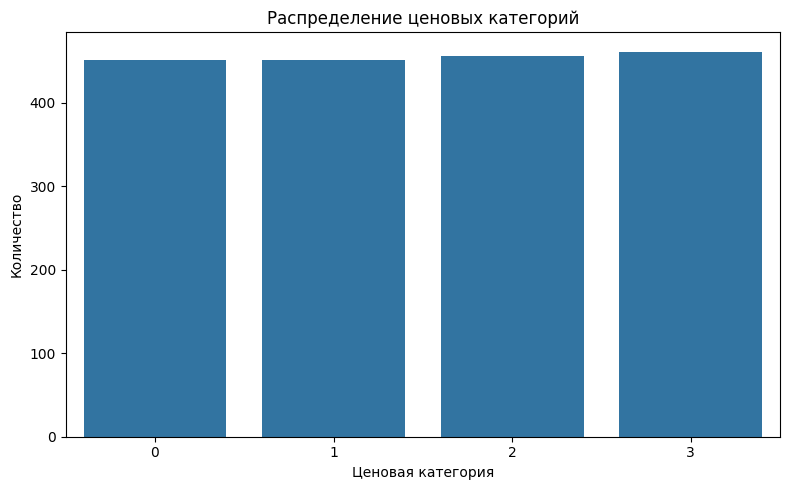

In [22]:
#График 1 — распределение target
plt.figure(figsize=(8, 5))

sns.countplot(
    data=clean_df,
    x="price_range"
)

plt.title("Распределение ценовых категорий")
plt.xlabel("Ценовая категория")
plt.ylabel("Количество")

plt.tight_layout()
plt.savefig("graph1_price_range.png", dpi=150)
plt.show()

### Вывод

Все четыре ценовые категории представлены примерно одинаковым количеством
объектов. Следовательно, выраженного дисбаланса классов в данных нет.

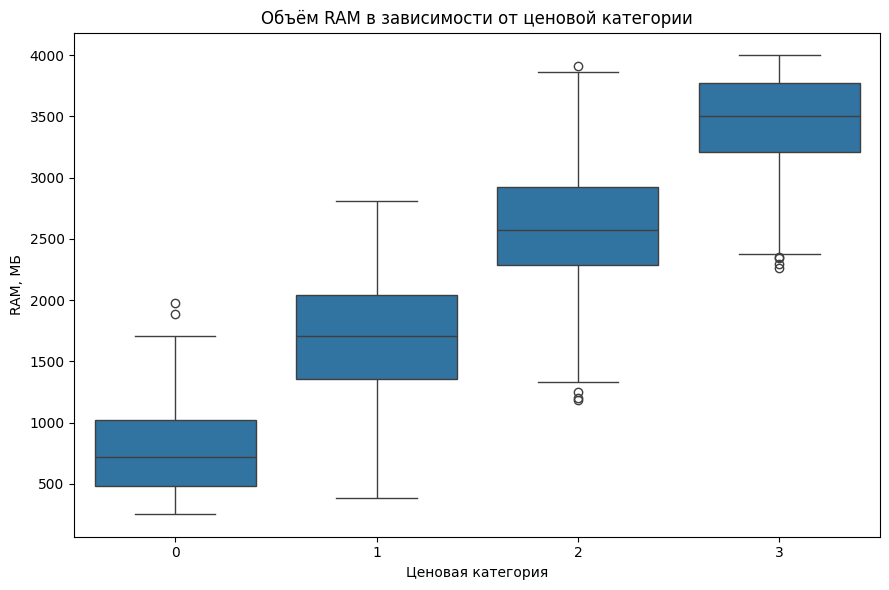

In [24]:
#График 2 — RAM и цена
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=clean_df,
    x="price_range",
    y="ram"
)

plt.title("Объём RAM в зависимости от ценовой категории")
plt.xlabel("Ценовая категория")
plt.ylabel("RAM, МБ")

plt.tight_layout()
plt.savefig("graph2_ram_price.png", dpi=150)
plt.show()

### Вывод

Объём оперативной памяти заметно увеличивается с ростом ценовой категории.
Телефоны категорий 2 и 3 в среднем обладают значительно большим объёмом RAM,
чем устройства категорий 0 и 1.

Следовательно, `ram` является одним из наиболее информативных признаков
для классификации ценового диапазона.

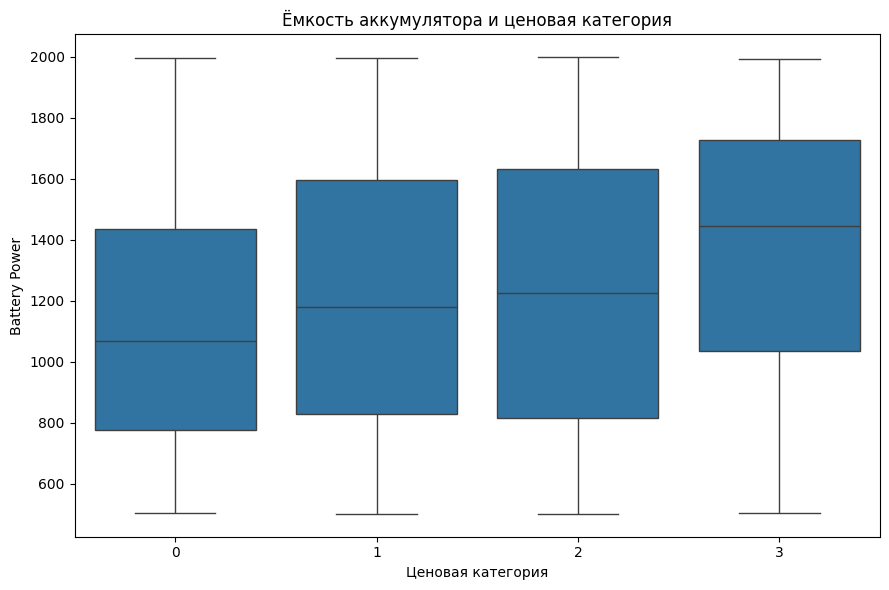

In [25]:
#График 3 — Battery Power
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=clean_df,
    x="price_range",
    y="battery_power"
)

plt.title("Ёмкость аккумулятора и ценовая категория")
plt.xlabel("Ценовая категория")
plt.ylabel("Battery Power")

plt.tight_layout()
plt.savefig("graph3_battery_price.png", dpi=150)
plt.show()

### Вывод

У более дорогих категорий наблюдается тенденция к увеличению мощности
аккумулятора, однако разделение классов выражено значительно слабее,
чем в случае оперативной памяти.

Признак `battery_power` может быть полезен модели, но сам по себе
недостаточен для определения ценовой категории.



In [26]:
#График 4 — корреляция
correlation = clean_df.corr(numeric_only=True)

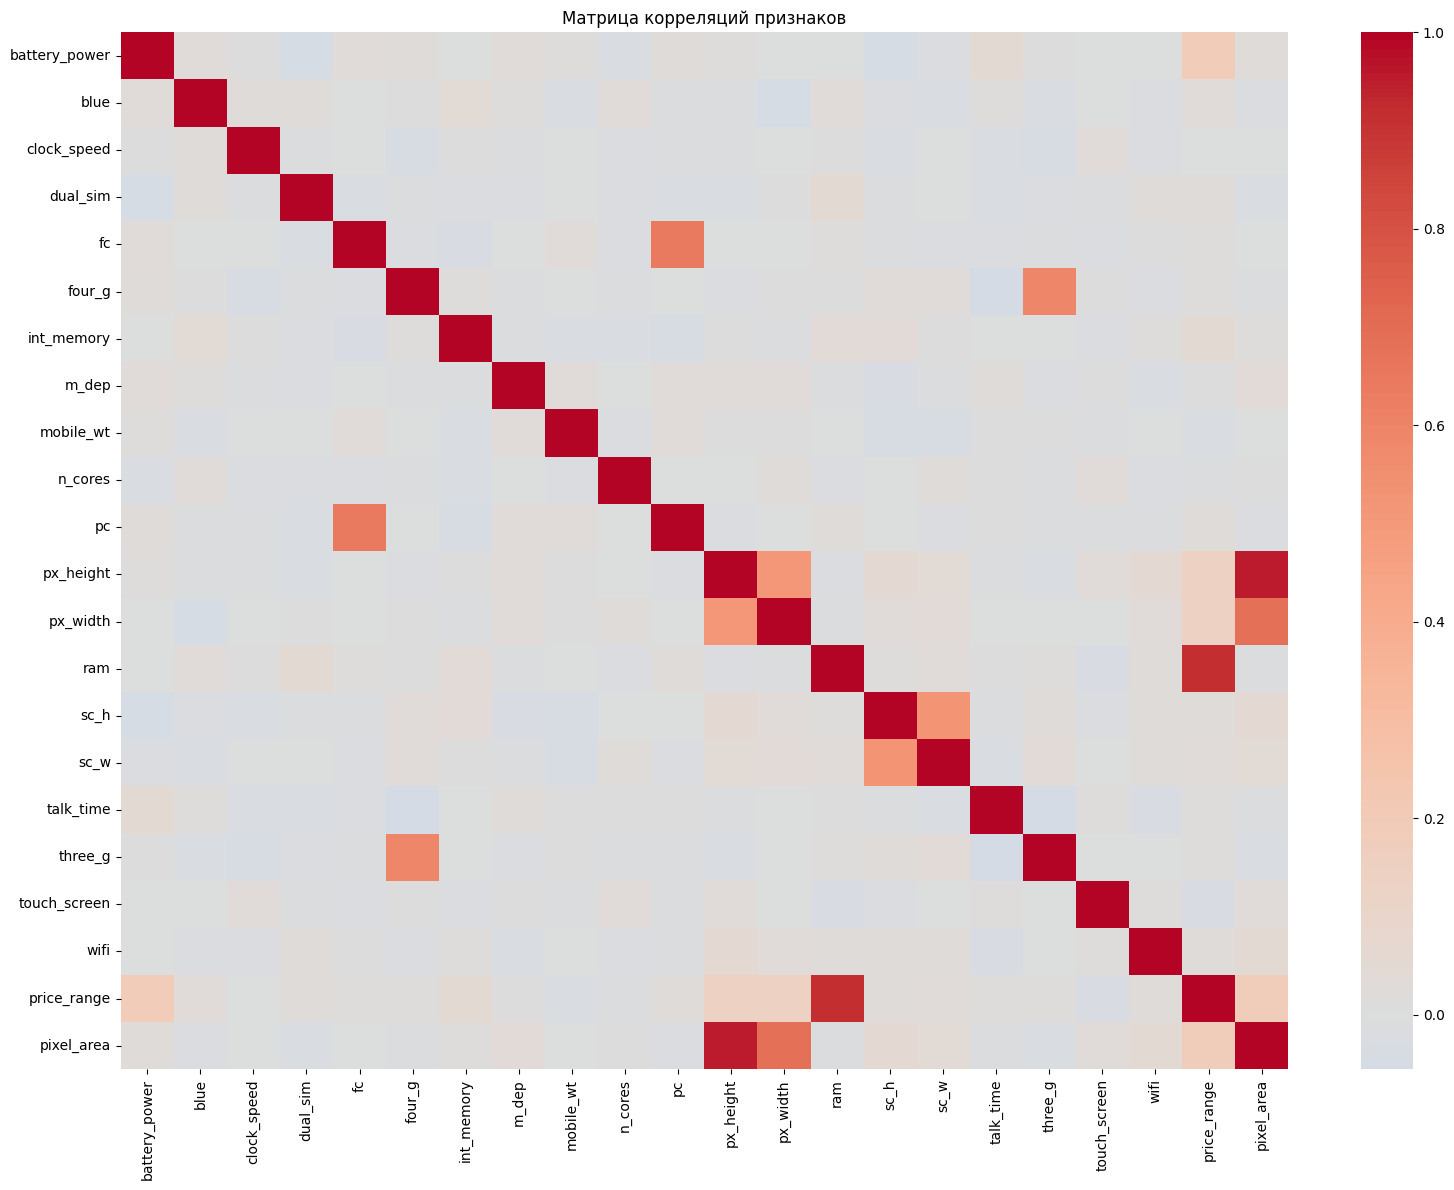

In [27]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Матрица корреляций признаков")

plt.tight_layout()
plt.savefig("graph4_correlation.png", dpi=150)
plt.show()

In [28]:
correlation["price_range"].sort_values(ascending=False)

price_range      1.000000
ram              0.917045
battery_power    0.193879
pixel_area       0.173365
px_width         0.150435
px_height        0.149783
int_memory       0.051512
sc_w             0.031775
blue             0.028674
sc_h             0.024171
pc               0.023224
dual_sim         0.022761
wifi             0.020652
fc               0.017528
three_g          0.016910
four_g           0.014578
talk_time        0.010925
m_dep            0.003151
clock_speed     -0.003857
n_cores         -0.009938
mobile_wt       -0.023780
touch_screen    -0.033778
Name: price_range, dtype: float64

### Вывод

Наиболее выраженная положительная связь с целевой переменной наблюдается
у признака `ram`.

Также положительную связь с ценовой категорией показывают характеристики
аккумулятора и разрешения экрана (`battery_power`, `px_width`,
`px_height`).

Большинство остальных признаков имеют значительно более слабую линейную
связь с целевой переменной.

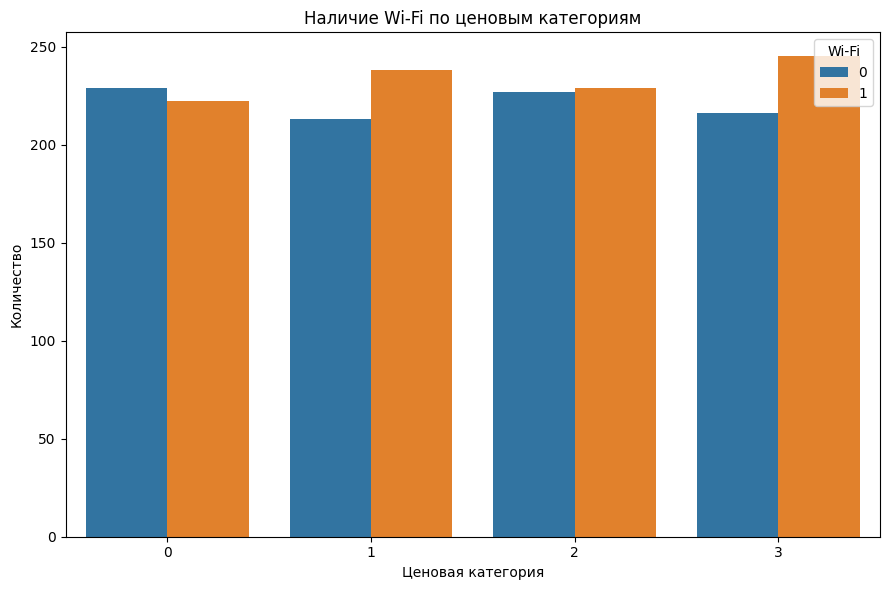

In [29]:
#График 5 — Wi-Fi и ценовая категория
plt.figure(figsize=(9, 6))

sns.countplot(
    data=clean_df,
    x="price_range",
    hue="wifi"
)

plt.title("Наличие Wi-Fi по ценовым категориям")
plt.xlabel("Ценовая категория")
plt.ylabel("Количество")
plt.legend(title="Wi-Fi")

plt.tight_layout()
plt.savefig("graph5_wifi.png", dpi=150)
plt.show()

### Вывод

Наличие Wi-Fi распределено достаточно равномерно между различными
ценовыми категориями.

Поэтому сам по себе этот признак, вероятно, имеет небольшую
разделяющую способность при определении ценовой категории телефона.

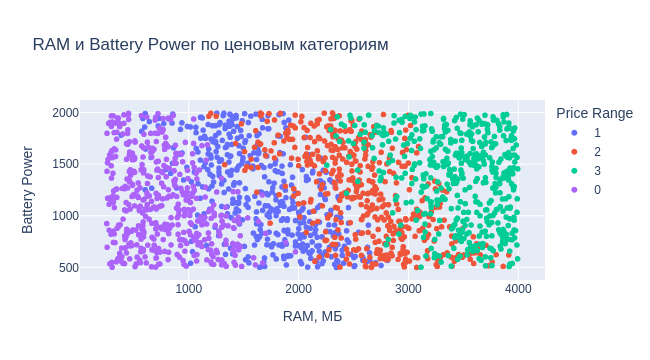

In [30]:
#График 6 — интерактивный
fig = px.scatter(
    clean_df,
    x="ram",
    y="battery_power",
    color=clean_df["price_range"].astype(str),
    hover_data=[
        "px_height",
        "px_width",
        "int_memory",
        "mobile_wt"
    ],
    title="RAM и Battery Power по ценовым категориям",
    labels={
        "ram": "RAM, МБ",
        "battery_power": "Battery Power",
        "color": "Price Range"
    }
)

fig.show()

In [31]:
fig.write_html("graph6_interactive.html")

### Вывод

Интерактивный график показывает, что разделение ценовых категорий особенно
хорошо прослеживается по объёму оперативной памяти.

При одинаковых значениях `battery_power` телефоны с большим объёмом RAM
чаще относятся к более высокой ценовой категории. Это дополнительно
подтверждает высокую информативность признака `ram`.

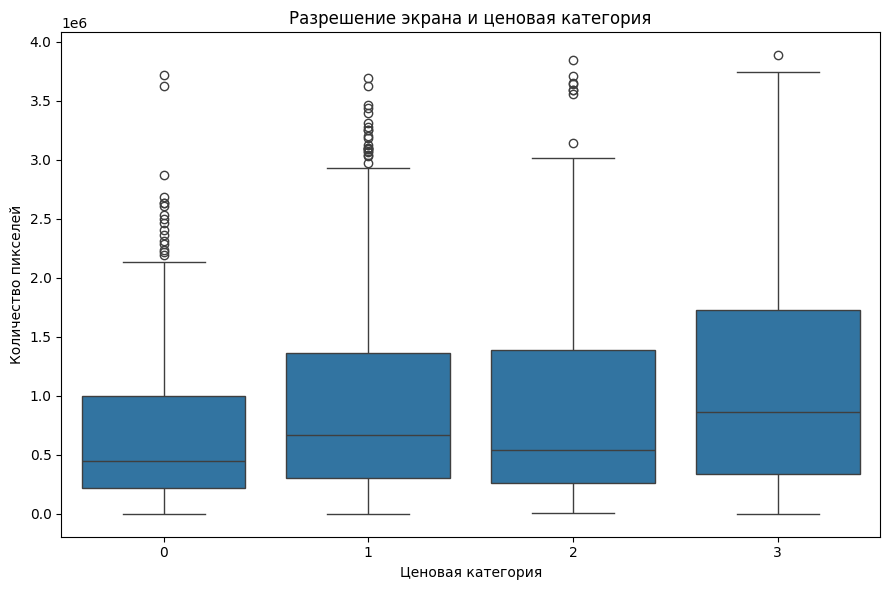

In [32]:
#6. Дополнительный график по новому признаку
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=clean_df,
    x="price_range",
    y="pixel_area"
)

plt.title("Разрешение экрана и ценовая категория")
plt.xlabel("Ценовая категория")
plt.ylabel("Количество пикселей")

plt.tight_layout()
plt.savefig("graph7_pixel_area.png", dpi=150)
plt.show()

### Вывод

У более высоких ценовых категорий наблюдается тенденция к увеличению
общего разрешения экрана, однако пересечения между классами остаются
значительными.

Признак `pixel_area` может дополнять другие характеристики устройства,
но не является таким сильным фактором, как объём RAM.

In [33]:
# 4. Сохранение финального датасета
clean_df.to_pickle("../data/clean_dataset.pkl")
print("Финальный размер датасета:", clean_df.shape)
pd.read_pickle("../data/clean_dataset.pkl").head()

Финальный размер датасета: (1819, 22)


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range,pixel_area
0,842,0,2.2,0,1,0,7,0.6,188,2,...,756,2549,9,7,19,0,0,1,1,15120
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,1988,2631,17,3,7,1,1,0,2,1799140
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1716,2603,11,2,9,1,1,0,2,2167308
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1786,2769,16,8,11,1,0,0,2,2171776
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1212,1411,8,2,15,1,1,0,1,1464096


# 5. Выводы

В ходе разведочного анализа данных были выполнены следующие действия:

1. Загружен и изучен датасет Mobile Price Classification.
2. Определена целевая переменная `price_range`.
3. Признаки были разделены на числовые и категориальные.
4. Проверено наличие пропущенных значений и дубликатов.
5. Проведена проверка признаков на невалидные значения.
6. Удалены записи с невозможными нулевыми размерами или разрешением экрана.
7. Бинарные категориальные признаки приведены к типу `int8`.
8. Создан новый признак `pixel_area`.
9. Построены статические и интерактивные графики.
10. Очищенный датасет сохранён в `data/clean_dataset.pkl`.

В результате анализа установлено:

- целевая переменная сбалансирована по четырём классам;
- наиболее сильная зависимость ценовой категории наблюдается от объёма RAM;
- `battery_power`, `px_width` и `px_height` также имеют связь с ценовой категорией;
- бинарные признаки, такие как Wi-Fi, Bluetooth и поддержка двух SIM-карт,
  сами по себе слабо разделяют ценовые категории;
- характеристики разрешения экрана могут быть полезны в сочетании
  с другими признаками.

Полученный очищенный датасет будет использоваться в последующих
лабораторных работах.